### Proyecto Machine Learning


In [257]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
import pickle
from sklearn.feature_selection import f_classif, SelectKBest
import warnings

### Airbnb en Nueva York

Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

### Paso 1: Carga del conjunto de datos

In [258]:
data_airbi_ny = pd.read_csv("/workspaces/Antonio27M-machine-learning/data/raw/internal-link.csv")
data_airbi_ny.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### Paso 2: Realiza un EDA completo

In [259]:
df = data_airbi_ny.drop(columns=['id', 'host_id','calculated_host_listings_count','latitude','longitude'])
df.head()

,name,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,availability_365
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,365
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,355
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room,150,3,0,NaN,NaN,365
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,194
4,Entire Apt: Spacious Studio/Loft by central park,Laura,Manhattan,East Harlem,Entire home/apt,80,10,9,2018-11-19,0.10,0


>### Observación: 
>
>Uso. Drop() para eliminar columnas que no me interesan directamente, mi principal análisis va enfocando en la variable precio.

In [260]:
df.columns
#'nombre', 'nombre_del_anfitrión', 
#'grupo_de_vecindario', 'vecindario', 'latitud', 
#'longitud', 'tipo_de_habitación', 'precio', 'noches_mínimas', 
#'número_de_reseñas', 'última_reseña', 'reseñas_por_mes', 
#'número_calculado_de_anfitriones_anuncios', 'disponibilidad_365', dtype='object'


Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'availability_365'],
      dtype='object')

In [261]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 48879 non-null  object 
 1   host_name            48874 non-null  object 
 2   neighbourhood_group  48895 non-null  object 
 3   neighbourhood        48895 non-null  object 
 4   room_type            48895 non-null  object 
 5   price                48895 non-null  int64  
 6   minimum_nights       48895 non-null  int64  
 7   number_of_reviews    48895 non-null  int64  
 8   last_review          38843 non-null  object 
 9   reviews_per_month    38843 non-null  float64
 10  availability_365     48895 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 4.1+ MB


In [262]:
df.fillna({'reviews_per_month': 0}, inplace=True)
df.isnull().sum()

name                      16
host_name                 21
neighbourhood_group        0
neighbourhood              0
room_type                  0
price                      0
minimum_nights             0
number_of_reviews          0
last_review            10052
reviews_per_month          0
availability_365           0
dtype: int64

In [263]:
df.drop_duplicates(inplace=True)

>### Observación: 
>
>Las siguientes casillas comienzo a trabajar para conocer mis valores faltantes, verificar si hay algún duplicado y saber si sé eliminar >correctamente las columnas no deseadas.

In [264]:
df[df["price"] == 0].shape[0]
df.drop(index=df.index[df["price"] == 0], inplace=True)

In [265]:
df[df["availability_365"] == 0].shape[0]
df.drop(index=df.index[df["availability_365"] == 0], inplace=True)

In [266]:
df['room_type'].value_counts()

room_type
Entire home/apt    16523
Private room       13952
Shared room          862
Name: count, dtype: int64

In [267]:
df_factorize = df.copy()

In [268]:
df_factorize['number_roomtype'] = pd.factorize(df['room_type'])[0]


In [269]:
df['number_roomtype'] = pd.factorize(df['room_type'])[0]
df['number_roomtype'].value_counts()

number_roomtype
1    16523
0    13952
2      862
Name: count, dtype: int64

In [270]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        13549
Brooklyn         12252
Queens            4292
Bronx              913
Staten Island      331
Name: count, dtype: int64

In [271]:
df['number_group'] = pd.factorize(df['neighbourhood_group'])[0]
df['number_group'].value_counts()


number_group
1    13549
0    12252
2     4292
4      913
3      331
Name: count, dtype: int64

>### Observación: 
>
>En las siguientes casillas procedo a eliminar valores que no tienen sentido como precio = 0, su disponibilidad = 0, ya que no está >disponible en el mercado. 
>
>También realice cambios en mis datos 'string' a numéricos para luego trabajarlos en mi modelo, realice un 'dicc' de sus nombres, >guardándolos en un archivo de texto (json) para recordar su numeración con su respectivo nombre.

In [272]:
df_region = df
df_region.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31337 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 31333 non-null  object 
 1   host_name            31329 non-null  object 
 2   neighbourhood_group  31337 non-null  object 
 3   neighbourhood        31337 non-null  object 
 4   room_type            31337 non-null  object 
 5   price                31337 non-null  int64  
 6   minimum_nights       31337 non-null  int64  
 7   number_of_reviews    31337 non-null  int64  
 8   last_review          26147 non-null  object 
 9   reviews_per_month    31337 non-null  float64
 10  availability_365     31337 non-null  int64  
 11  number_roomtype      31337 non-null  int64  
 12  number_group         31337 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 3.3+ MB


In [273]:
df_region

,name,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,availability_365,number_roomtype,number_group
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,365,0,0
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,355,1,1
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room,150,3,0,NaN,0.00,365,0,1
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,194,1,0
5,Large Cozy 1 BR Apartment In Midtown East,Chris,Manhattan,Murray Hill,Entire home/apt,200,3,74,2019-06-22,0.59,129,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Charming one bedroom - newly renovated rowhouse,Sabrina,Brooklyn,Bedford-Stuyvesant,Private room,70,2,0,NaN,0.00,9,0,0
48891,Affordable room in Bushwick/East Williamsburg,Marisol,Brooklyn,Bushwick,Private room,40,4,0,NaN,0.00,36,0,0
48892,Sunny Studio at Historical Neighborhood,Ilgar & Aysel,Manhattan,Harlem,Entire home/apt,115,10,0,NaN,0.00,27,1,1
48893,43rd St. Time Square-cozy single bed,Taz,Manhattan,Hell's Kitchen,Shared room,55,1,0,NaN,0.00,2,2,1


In [274]:
df_region.fillna({'reviews_per_month': 0},inplace=True)

In [275]:
df_region.head()

,name,host_name,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,availability_365,number_roomtype,number_group
0,Clean & quiet apt home by the park,John,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,365,0,0
1,Skylit Midtown Castle,Jennifer,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,355,1,1
2,THE VILLAGE OF HARLEM....NEW YORK !,Elisabeth,Manhattan,Harlem,Private room,150,3,0,NaN,0.00,365,0,1
3,Cozy Entire Floor of Brownstone,LisaRoxanne,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,194,1,0
5,Large Cozy 1 BR Apartment In Midtown East,Chris,Manhattan,Murray Hill,Entire home/apt,200,3,74,2019-06-22,0.59,129,1,1


In [276]:
df_region.describe().T

,count,mean,std,min,25%,50%,75%,max
price,31337.0,162.073364,254.490947,10.0,70.00,111.00,189.00,10000.0
minimum_nights,31337.0,8.333982,23.842431,1.0,2.00,3.00,5.00,1250.0
number_of_reviews,31337.0,31.866643,51.647234,0.0,2.00,10.00,39.00,629.0
reviews_per_month,31337.0,1.510282,1.781338,0.0,0.17,0.92,2.34,58.5
availability_365,31337.0,175.738552,126.161865,1.0,55.00,167.00,305.00,365.0
number_roomtype,31337.0,0.582283,0.546126,0.0,0.00,1.00,1.00,2.0
number_group,31337.0,0.854517,0.900701,0.0,0.00,1.00,1.00,4.0


>### Observación: 
>
>
>Termino de eliminar columnas que no necesito para mi análisis, comienzo a gráficas mis variables categóricas para entender su comportamiento.

In [277]:
df_region.columns

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'last_review', 'reviews_per_month', 'availability_365',
       'number_roomtype', 'number_group'],
      dtype='object')

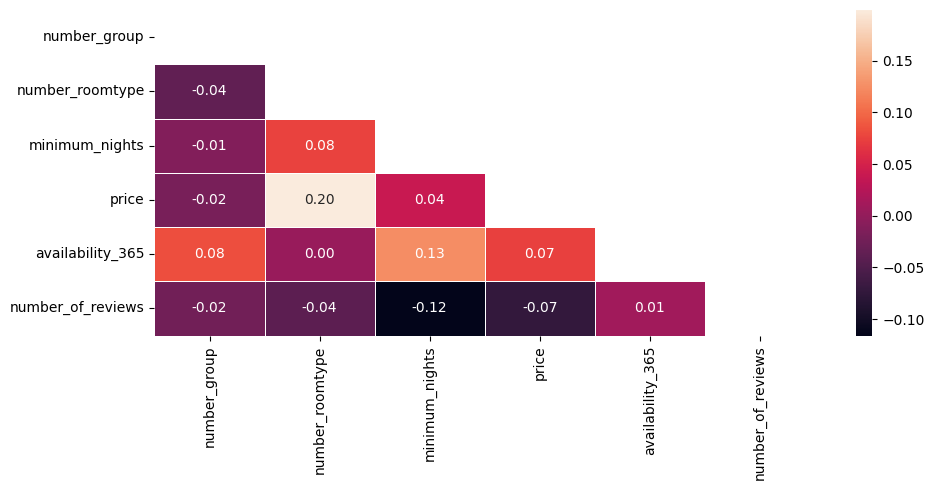

In [278]:
corr = df_region[['number_group','number_roomtype','minimum_nights','price','availability_365','number_of_reviews']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 5))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

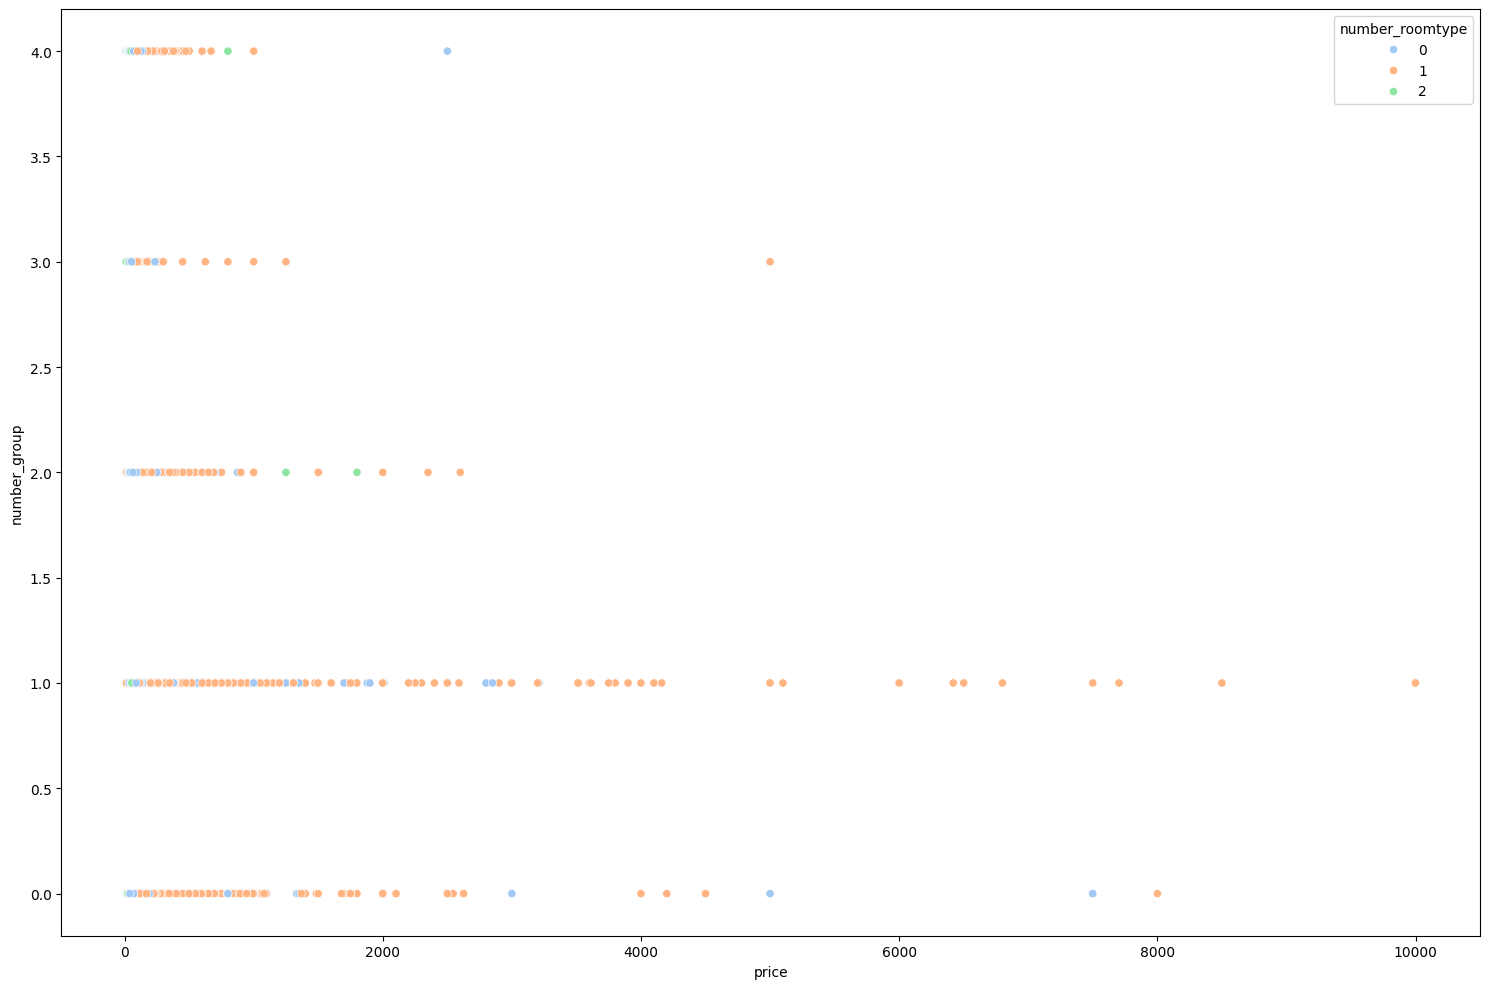

In [279]:
plt.figure(figsize=(15,10))
sns.scatterplot(data=df_region, x='price', y='number_group', hue='number_roomtype', palette='pastel')
plt.tight_layout()
plt.show()

>### Observación: 
>
>
>Género un gráfico de correlación para visualizar las variables que estén cercanas entre sí, como podemos observar hay una correlación de 0.>31 en longitud y latitud, como también una pequeña correlación de nuestro target que es precio con el tipo de habitación. 
>
>Por la cual procedo a generar un gráfico para observar su comportamiento, lo que se puede observar es que hay un mayor cantidad de >apartamentos por un mayor a 2000 que otros tipos de habitación, predomina más la región Manhattan.

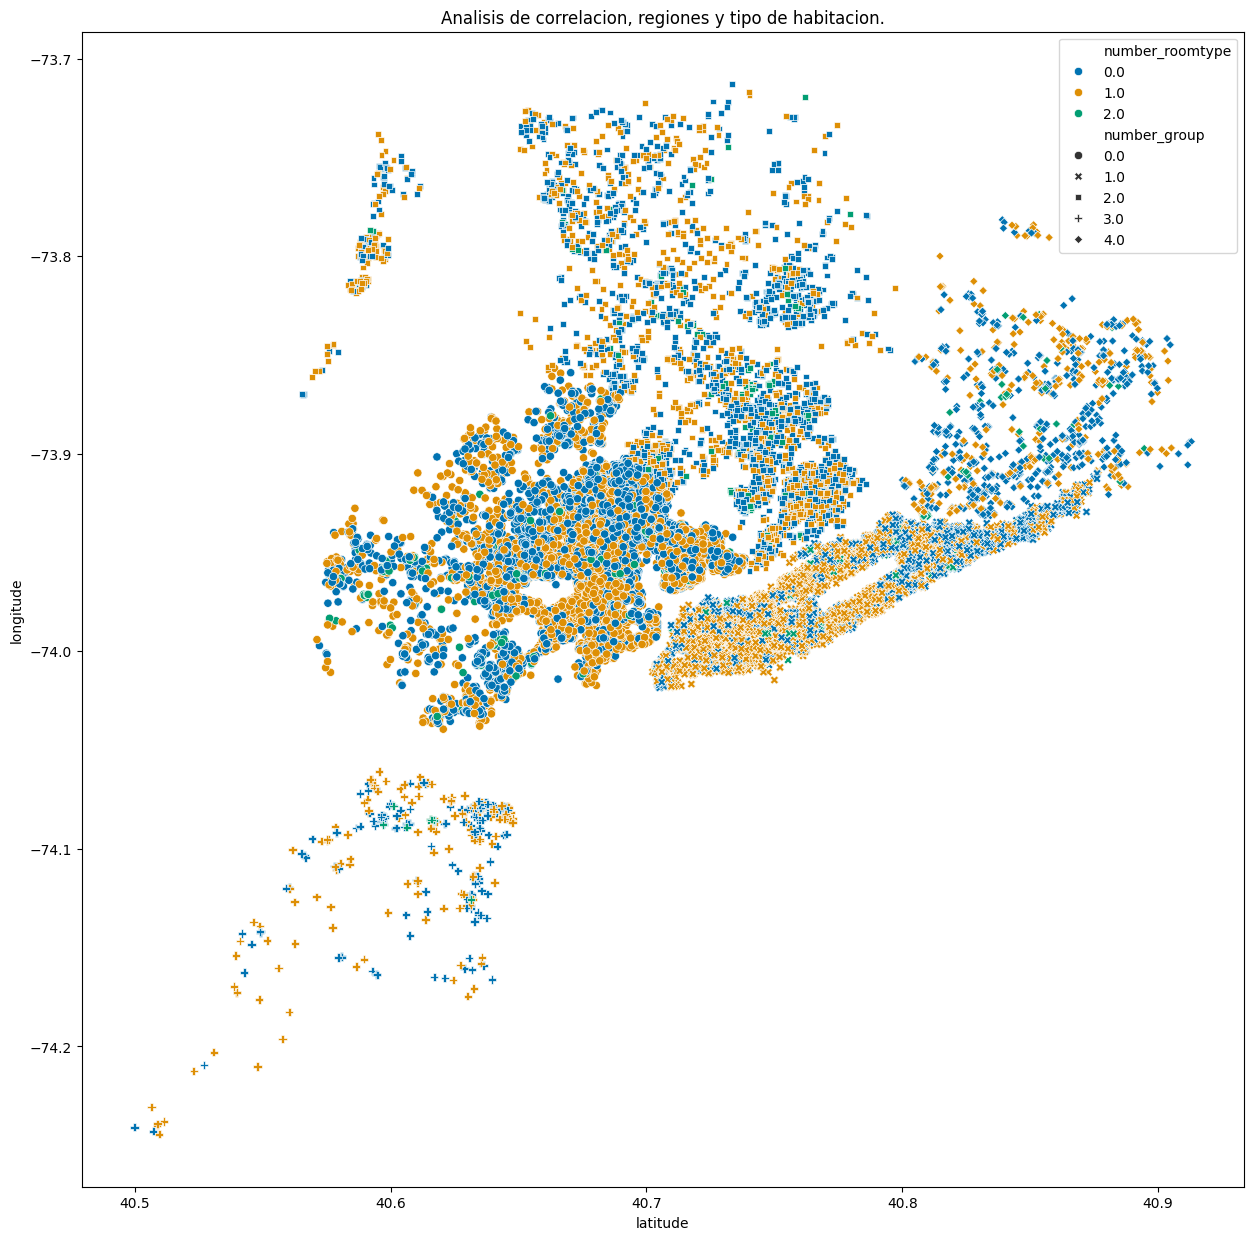

In [280]:
plt.figure(figsize=(15, 15))
sns.scatterplot(data=data_airbi_ny, x='latitude', y='longitude', hue=df_region['number_roomtype'], style=df_region['number_group'], palette='colorblind')
plt.title('Analisis de correlacion, regiones y tipo de habitacion.')
plt.show()

>### Observación: 
>
>Uso las coordenadas disponibles para tener mayor visualización en el mapa, región y tipo de habitación.
>Tomando en consideración todos los datos analizados anteriormente comenzamos a eliminar columnas que considero que no son fundamentales para mi análisis. 

In [281]:
df_region.drop(columns=['name', 'host_name', 'neighbourhood', 'last_review'], inplace=True)

In [282]:
df_region.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31337 entries, 0 to 48894
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  31337 non-null  object 
 1   room_type            31337 non-null  object 
 2   price                31337 non-null  int64  
 3   minimum_nights       31337 non-null  int64  
 4   number_of_reviews    31337 non-null  int64  
 5   reviews_per_month    31337 non-null  float64
 6   availability_365     31337 non-null  int64  
 7   number_roomtype      31337 non-null  int64  
 8   number_group         31337 non-null  int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 3.4+ MB


In [283]:
X = df_region.drop('price', axis=1)
y = df_region['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

In [284]:
min_max_scaler = MinMaxScaler()  

num_variables = ['number_group','number_roomtype','minimum_nights','availability_365','number_of_reviews']
min_max_features = min_max_scaler.fit_transform(X_train[num_variables])
min_max_features_test = min_max_scaler.transform(X_test[num_variables])
df_min_max_test = pd.DataFrame(min_max_features_test, index=X_test.index, columns=num_variables)
df_min_max_train = pd.DataFrame(min_max_features, index=X_train.index, columns=num_variables)

In [285]:
cat_variables = ['neighbourhood_group','room_type']
onehot_encoder = OneHotEncoder(sparse_output=False)

onehot_encoder.fit(X_train[cat_variables])

X_train_cat_ohe = onehot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe, index=X_train.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe, index=X_test.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

In [286]:
X_train_seg = pd.concat([X_train.drop(columns=cat_variables), X_train_cat_ohe], axis=1)
X_test_seg = pd.concat([X_test.drop(columns=cat_variables), X_test_cat_ohe], axis=1)
X_train_final = pd.concat([X_train_seg.drop(columns=num_variables), df_min_max_train], axis=1)
X_test_final = pd.concat([X_test_seg.drop(columns=num_variables), df_min_max_test], axis=1)


In [287]:
X_train_final.head()

,reviews_per_month,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,number_group,number_roomtype,minimum_nights,availability_365,number_of_reviews
28494,0.19,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.0,0.015212,0.980769,0.001590
7782,0.00,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.50,0.0,0.000000,1.000000,0.000000
20937,0.79,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.0,0.000000,0.420330,0.028617
1629,0.26,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.00,0.5,0.023219,0.686813,0.033386
11350,0.67,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.25,0.5,0.008807,0.239011,0.042925


In [289]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25069 entries, 28494 to 45381
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   reviews_per_month                  25069 non-null  float64
 1   neighbourhood_group_Bronx          25069 non-null  float64
 2   neighbourhood_group_Brooklyn       25069 non-null  float64
 3   neighbourhood_group_Manhattan      25069 non-null  float64
 4   neighbourhood_group_Queens         25069 non-null  float64
 5   neighbourhood_group_Staten Island  25069 non-null  float64
 6   room_type_Entire home/apt          25069 non-null  float64
 7   room_type_Private room             25069 non-null  float64
 8   room_type_Shared room              25069 non-null  float64
 9   number_group                       25069 non-null  float64
 10  number_roomtype                    25069 non-null  float64
 11  minimum_nights                     25069 non-null  floa

In [288]:
X_test_final.head()

,reviews_per_month,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room,number_group,number_roomtype,minimum_nights,availability_365,number_of_reviews
41011,0.75,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.50,0.0,0.000801,0.873626,0.003180
2238,1.26,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.00,0.5,0.002402,0.686813,0.151033
13714,0.33,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.0,0.003203,0.241758,0.020668
34083,3.30,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.25,0.5,0.000801,0.480769,0.060413
29619,0.32,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.25,0.0,0.023219,0.909341,0.007949


In [290]:
X_test_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6268 entries, 41011 to 34991
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   reviews_per_month                  6268 non-null   float64
 1   neighbourhood_group_Bronx          6268 non-null   float64
 2   neighbourhood_group_Brooklyn       6268 non-null   float64
 3   neighbourhood_group_Manhattan      6268 non-null   float64
 4   neighbourhood_group_Queens         6268 non-null   float64
 5   neighbourhood_group_Staten Island  6268 non-null   float64
 6   room_type_Entire home/apt          6268 non-null   float64
 7   room_type_Private room             6268 non-null   float64
 8   room_type_Shared room              6268 non-null   float64
 9   number_group                       6268 non-null   float64
 10  number_roomtype                    6268 non-null   float64
 11  minimum_nights                     6268 non-null   float

>### Observación: 
>
>
>Hay varios valores anormales en la gráfica target, ya teniendo mis variables categóricas en numéricas, procedemos a transformar nuestros >datos en relación 0 a 1 para utilizarlo en nuestro modelo.